<a href="https://colab.research.google.com/github/mixxr/gcolab-ml/blob/main/funnel/06_qsar_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Episode 6 — Build a QSAR Model
**Drug Discovery in Code** · [Life Sciences AI Applications]
So far we've *searched* for molecules. Now we'll **predict**. A **QSAR** model — Quantitative
Structure–Activity Relationship — learns the link between a molecule's structure and its potency,
so you can score a molecule you've *never measured*. We'll featurise our EGFR set as fingerprints,
train a random forest to predict pIC50, and honestly evaluate it on a held-out test set.
> Educational only — not medical advice.

## Setup — features and target
The recipe of nearly every ML model in cheminformatics: **X = fingerprints, y = pIC50.**

In [1]:

! wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
! bash Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local

--2026-10-09 13:59:07--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197973354 (189M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.80M   264MB/s    in 0.7s    

2026-10-09 13:59:08 (264 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197973354/197973354]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please 

In [2]:
import sys
!{sys.executable} -m pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 20.7 MB/s eta 0:00:00


In [4]:
import numpy as np, pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

df = pd.read_csv("egfr_chembl.csv")
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

## 1. Featurise — molecules → number arrays
A model can't read a molecule, but it can read a vector. We turn each fingerprint into a NumPy
row, and stack them into a feature matrix `X`.

In [5]:
def to_array(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    fp = gen.GetFingerprint(m)
    arr = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

feats = df.smiles.apply(to_array)
df = df[feats.notna()].reset_index(drop=True)
X = np.stack(feats.dropna().values)
y = df.pIC50.values
X.shape, y.shape

((6297, 2048), (6297,))

## 2. Split — train vs test
The golden rule: **evaluate on data the model never saw.** Hold out 20% before training.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(5037, 1260)

## 3. Train a random forest
A random forest is a strong, no-fuss baseline for fingerprint QSAR — it handles thousands of
sparse binary features without much tuning.

**n_estimators** are the number of decision trees the model will build.
**n_jobs** is the number of CPU cores to use for parallel processing.

In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

## 4. Evaluate — honestly
**R²** = fraction of variance explained (1.0 is perfect). **RMSE** = typical error, in pIC50 units.

In [10]:
from sklearn.metrics import r2_score, mean_squared_error

pred = model.predict(X_test)
r2   = r2_score(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5

print(f"R2   = {r2:.2f}")
print(f"RMSE = {rmse:.2f} pIC50 units")

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]]
R2   = 0.73
RMSE = 0.72 pIC50 units


In [13]:
smile = "NC[C@H](Cc1cccc(F)c1)NC(=O)c1cc(Br)c(-c2ccnc3[nH]ccc23)s1"
m = Chem.MolFromSmiles(smile)
fp = gen.GetFingerprint(m)
arr = np.zeros((2048,), dtype=np.int8)
DataStructs.ConvertToNumpyArray(fp, arr)
# predict pIC50
ip50 = model.predict(arr.reshape(1, -1))
print(f"pIC50 = {ip50[0]:.2f}")

pIC50 = 5.24


## 5. See it — predicted vs measured
The honest plot: every held-out molecule, predicted against its real value. Points near the
dashed diagonal are good predictions; scatter around it is the model's error.

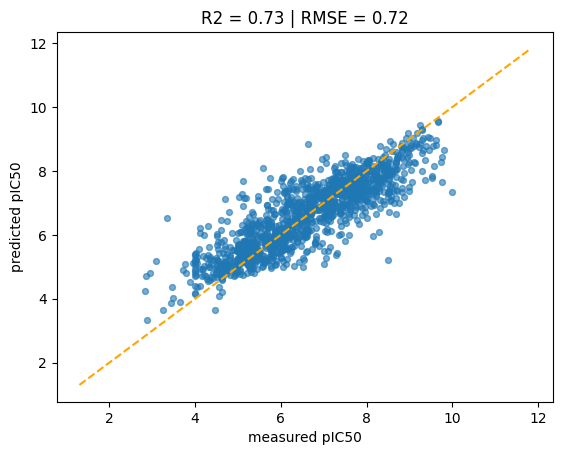

In [9]:
import matplotlib.pyplot as plt
plt.scatter(y_test, pred, s=18, alpha=.6)
lims = [y.min()-.3, y.max()+.3]
plt.plot(lims, lims, "--", c="orange")
plt.xlabel("measured pIC50"); plt.ylabel("predicted pIC50")
plt.title(f"R2 = {r2:.2f} | RMSE = {rmse:.2f}"); plt.show()

An R² around **0.7** with a ~0.8 pIC50 error is a realistic result for a plain fingerprint model —
good enough to **rank** and **triage** molecules, not to trust to two decimals. That's the honest
state of QSAR: a fast filter, not an oracle. In Episode 8 we'll use exactly this kind of model to
score molecules we've never made.

## Recap
- **QSAR** learns structure → activity, so you can score unmeasured molecules.
- The standard setup: **X = fingerprints, y = pIC50**.
- Always evaluate on a **held-out test set** — R² and RMSE.
- A random forest gives a solid, honest baseline (R² ≈ 0.7 here).

**Next — Episode 7:** leave 2-D behind — load the **EGFR protein structure** and **dock** a
molecule into its binding site.